In [29]:
import json
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

In [39]:
metadata_wind_farms = {
      "wind_farms": [
        {
          "id": "Borssele_12",
          "name": "Borssele 1&2",
          "installed_capacity_mw": 752, #source https://orsted.nl/duurzame-energie/wind-op-zee/borssele-1-en-2
          "location": {
            "lat": 51.75,
            "lon": 3.25
          },
          "commissioned": "27/11/2020",
          "turbine_type": "SG 8.0-167 DD",
          "platform_height": 116.5,
          "wind_height_scaling_factor": 1,
          "offshore_data_available" : True,
          "turbines": 94
        },
        {
          "id": "Borssele_34",
          "name": "Borssele 3&4",
          "installed_capacity_mw": 731.5,
          "location": {
            "lat": 51.72,
            "lon": 3.22
          },
          "commissioned": "06/01/2021",
          "turbine_type": "V164-9.5",
          "platform_height": 100,
          "wind_height_scaling_factor": 1,
          "offshore_data_available" : True,
          "turbines": 77
        },
        {
          "id": "Gemini",
          "name": "Gemini",
          "installed_capacity_mw": 600,
          "location": {
            "lat": 54.03,
            "lon": 5.95
          },
          "commissioned": "08/05/2017",
          "turbine_type": "SWT-4.0-130",
          "platform_height": 120,
          "wind_height_scaling_factor": 1,
          "offshore_data_available" : True,
          "turbines": 150
        },
        {
          "id": "Hollandse_Kust_Zuid",
          "name": "Hollandse Kust Zuid",
          "installed_capacity_mw": 1529, #source https://powerplants.vattenfall.com/hollandse-kust-zuid/
          "location": {
            "lat": 52.35,
            "lon": 4.25
          },
          "commissioned": "29/09/2023",
          "turbine_type": "SG 11.0-200 DD",
          "platform_height": 125.5,
          "wind_height_scaling_factor": 1,
          "offshore_data_available" : True,
          "turbines": 139
        },
        {
          "id": "Hollandse_Kust_Noord",
          "name": "Hollandse Kust Noord",
          "installed_capacity_mw": 759,
          "location": {
            "lat": 52.75,
            "lon": 4.5
          },
          "commissioned": "20/12/2023",
          "turbine_type": "SG 11.0-200 DD",
          "platform_height": 125.5,
          "wind_height_scaling_factor": 1,
          "offshore_data_available" : True,
          "turbines": 69
        },
        {
          "id": "Windfarm_Princess_Amalia",
          "name": "Windfarm Princess Amalia",
          "installed_capacity_mw": 120,
          "commissioned": "04/06/2008",
          "offshore_data_available" : False
        },
        {
          "id": "OWEZ",
          "name": "OWEZ",
          "installed_capacity_mw": 108,
          "commissioned": "18/04/2007",
          "offshore_data_available" : False
        },
        #   {
        #   "id": "Luchterduinen",
        #   "name": "Eneco Luchterduinen",
        #   "installed_capacity_mw": 129,
        #   "location": {
        #     "lat": 52.42,
        #     "lon": 4.17
        #   },
        #   "commissioned": "21/09/2015",
        #   "turbine_type": "V112-3.0",
        #   "platform_height": 84,
        #   "wind_height_scaling_factor": 1,
        #   "offshore_data_available": False,
        #   "turbines": 43
        # }
      ]
    }

In [40]:
with open("../datasets/metadata_wind_farms.json", "w") as f:
    json.dump(metadata_wind_farms, f, indent=2)

In [37]:
# Year range
metadata_wind_farms = metadata_wind_farms["wind_farms"]
current_year = datetime.now().year
years = list(range(2015, current_year + 1))

# Build a row per farm per year
rows = {year: {} for year in years}

for farm in metadata_wind_farms:
    name = farm["id"]
    capacity = farm["installed_capacity_mw"]
    commission_year = pd.to_datetime(farm["commissioned"], dayfirst=True).year

    for year in years:
        rows[year][name] = capacity if year >= commission_year else 0.0

# Build DataFrame
df_capacity = pd.DataFrame(rows).T.reset_index()
df_capacity = df_capacity.rename(columns={"index": "year"})

# Add total installed capacity column
farm_columns = [farm["id"] for farm in metadata_wind_farms]
df_capacity["total_installed_capacity_MW"] = df_capacity[farm_columns].sum(axis=1)

# Reorder columns
df_capacity = df_capacity[["year", "total_installed_capacity_MW"] + farm_columns]

print(df_capacity)

    year  total_installed_capacity_MW  Borssele_12  Borssele_34  Gemini  \
0   2015                        357.0          0.0          0.0     0.0   
1   2016                        357.0          0.0          0.0     0.0   
2   2017                        957.0          0.0          0.0   600.0   
3   2018                        957.0          0.0          0.0   600.0   
4   2019                        957.0          0.0          0.0   600.0   
5   2020                       1709.0        752.0          0.0   600.0   
6   2021                       2440.5        752.0        731.5   600.0   
7   2022                       2440.5        752.0        731.5   600.0   
8   2023                       4728.5        752.0        731.5   600.0   
9   2024                       4728.5        752.0        731.5   600.0   
10  2025                       4728.5        752.0        731.5   600.0   
11  2026                       4728.5        752.0        731.5   600.0   

    Hollandse_Kust_Zuid 

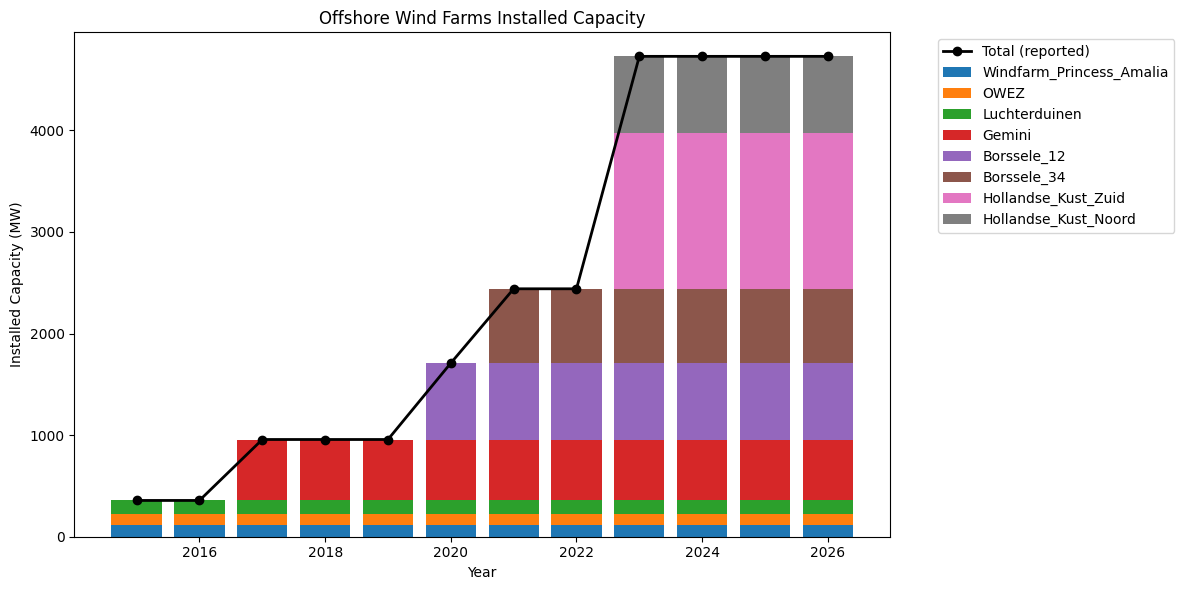

In [38]:
fig, ax = plt.subplots(figsize=(12, 6))

farm_columns = [col for col in df_capacity.columns if col not in ["year", "total_installed_capacity_MW"]]
farm_columns = sorted(farm_columns, key=lambda col: df_capacity[df_capacity[col] > 0]["year"].min())

bottom = [0] * len(df_capacity)
for col in farm_columns:
    ax.bar(df_capacity["year"], df_capacity[col], label=col, bottom=bottom)
    bottom = [b + v for b, v in zip(bottom, df_capacity[col])]

ax.plot(df_capacity["year"], df_capacity["total_installed_capacity_MW"], color="black", marker="o", linewidth=2, label="Total (reported)")

ax.set_xlabel("Year")
ax.set_ylabel("Installed Capacity (MW)")
ax.set_title("Offshore Wind Farms Installed Capacity")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [34]:
df_capacity.to_csv("../datasets/ENTSO_installed_capacity_offshore.csv", index=False)